In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [4]:
# Load dataset
diabetes = load_diabetes()

# Create DataFrame
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

print("Shape:", df.shape)
print("\nFirst 5 rows:")

df.head()

Shape: (442, 11)

First 5 rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
print("=== Dataset Description ===")
print(diabetes.DESCR[:1000])  # Print first 1000 chars of description

print("\n=== Basic Statistics ===")
df.describe()

=== Dataset Description ===
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 1

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [6]:
print("Missing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Missing values:
 age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Data types:
 age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object


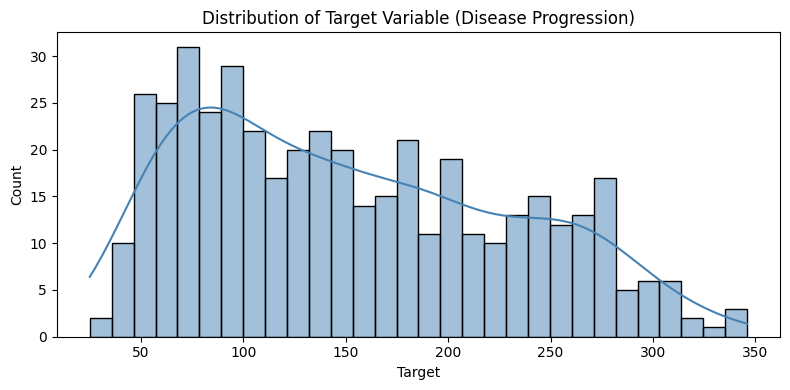

In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(df['target'], kde=True, bins=30, color='steelblue')
plt.title('Distribution of Target Variable (Disease Progression)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


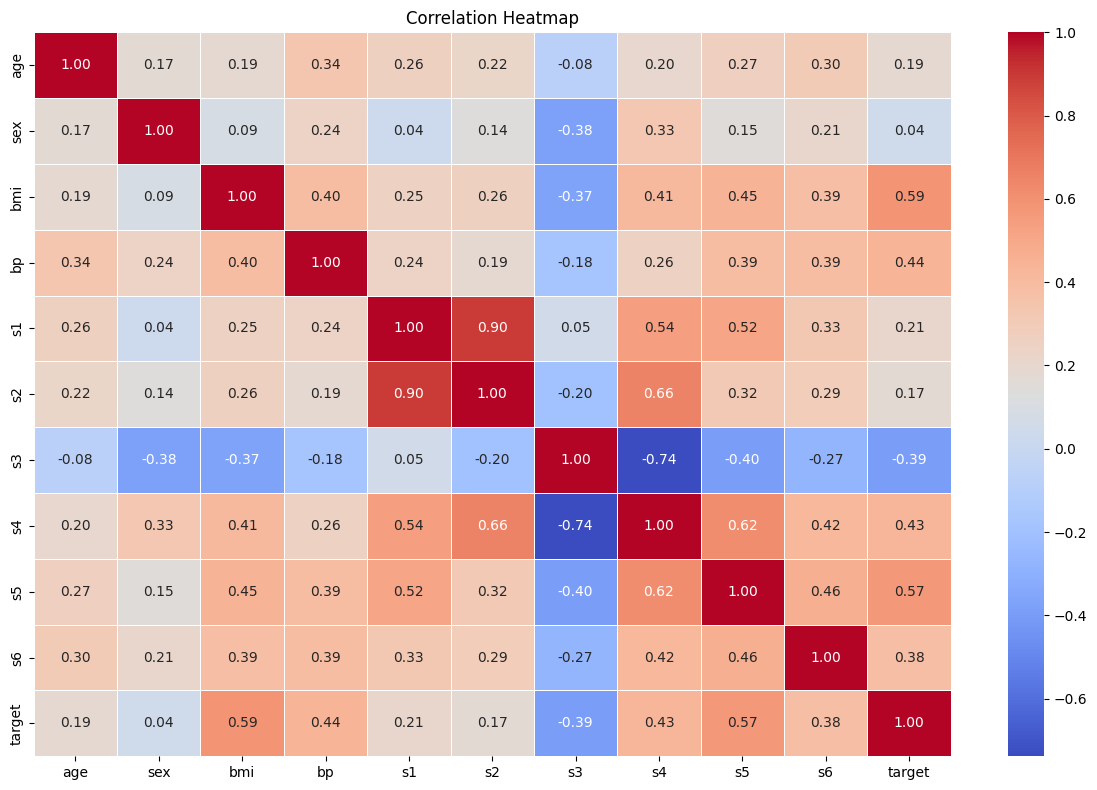

In [8]:
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

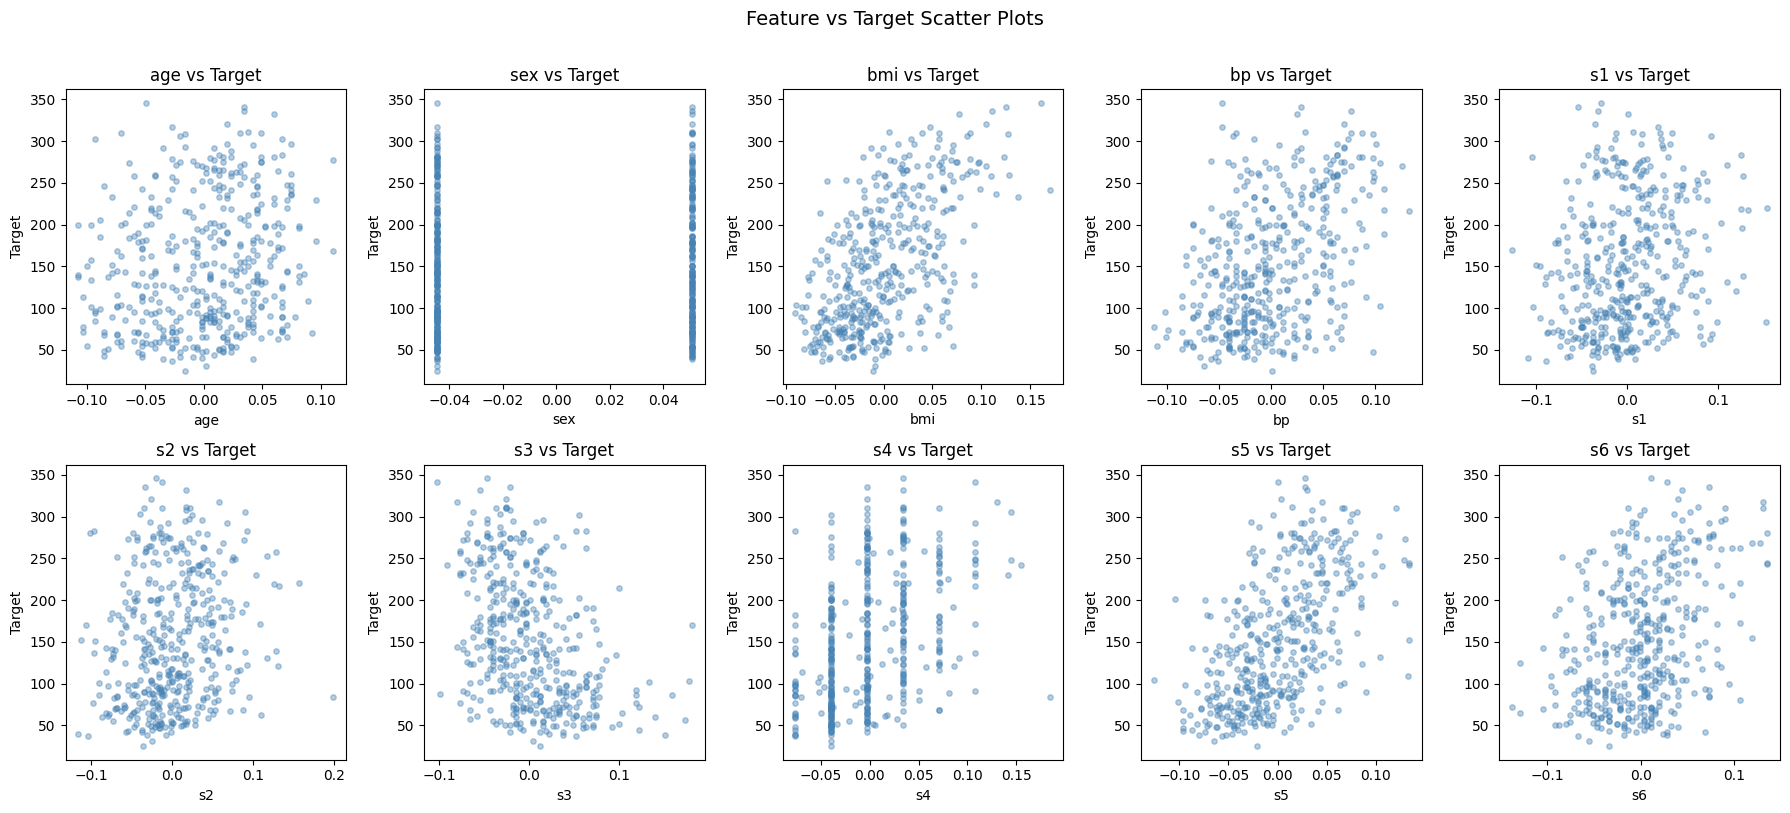

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(diabetes.feature_names):
    axes[i].scatter(df[col], df['target'], alpha=0.4, color='steelblue', s=15)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Target')
    axes[i].set_title(f'{col} vs Target')

plt.suptitle('Feature vs Target Scatter Plots', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [10]:
X = df.drop('target', axis=1)
y = df['target']

# 80% train, 20% test, random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size:     {X_test.shape}")

Training set size: (353, 10)
Test set size:     (89, 10)


In [11]:
# Note: LinearRegression doesn't strictly require scaling,
# but it helps with interpretability of coefficients
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete.")

Scaling complete.


In [12]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")
print(f"\nIntercept: {model.intercept_:.4f}")
print("\nCoefficients:")
coef_df = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df.to_string(index=False))

Model trained successfully!

Intercept: 153.7365

Coefficients:
Feature  Coefficient
     s1   -44.448856
     s5    35.161195
    bmi    25.607121
     s2    24.640954
     bp    16.828872
     s4    13.138784
    sex   -11.511809
     s3     7.676978
     s6     2.351364
    age     1.753758


In [13]:
y_pred = model.predict(X_test_scaled)

# Preview actual vs predicted
comparison = pd.DataFrame({
    'Actual':    y_test.values,
    'Predicted': y_pred.round(2),
    'Residual':  (y_test.values - y_pred).round(2)
})
print(comparison.head(10))

   Actual  Predicted  Residual
0   219.0     139.55     79.45
1    70.0     179.52   -109.52
2   202.0     134.04     67.96
3   230.0     291.42    -61.42
4   111.0     123.79    -12.79
5    84.0      92.17     -8.17
6   242.0     258.23    -16.23
7   272.0     181.34     90.66
8    94.0      90.22      3.78
9    96.0     108.63    -12.63


In [14]:
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=" * 35)
print("       MODEL EVALUATION METRICS")
print("=" * 35)
print(f"  MSE  (Mean Squared Error):  {mse:.2f}")
print(f"  RMSE (Root MSE):            {rmse:.2f}")
print(f"  MAE  (Mean Absolute Error): {mae:.2f}")
print(f"  R²   (R-Squared Score):     {r2:.4f}")
print("=" * 35)

       MODEL EVALUATION METRICS
  MSE  (Mean Squared Error):  2900.19
  RMSE (Root MSE):            53.85
  MAE  (Mean Absolute Error): 42.79
  R²   (R-Squared Score):     0.4526


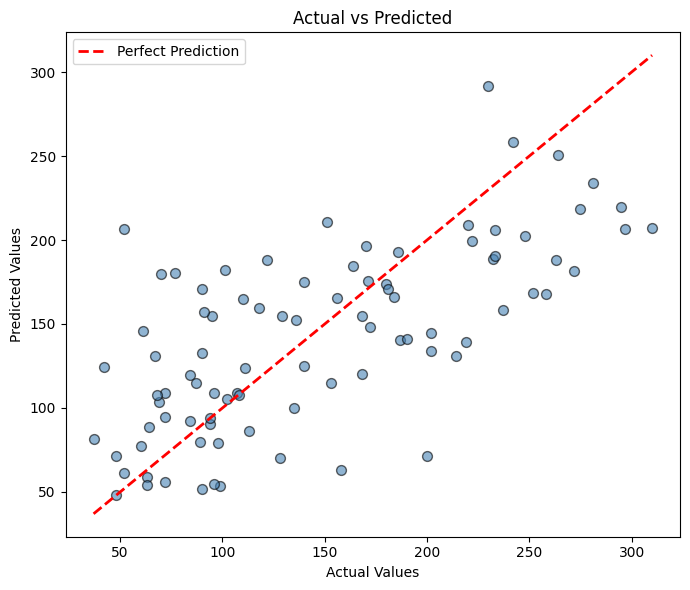

In [15]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='k', s=50)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

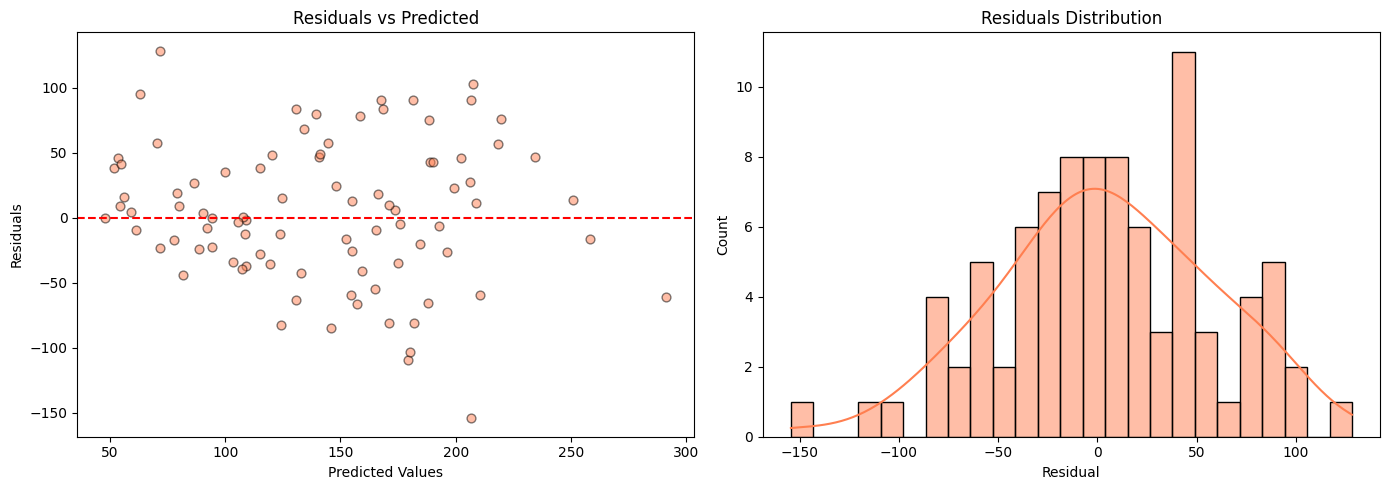

In [16]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.5, color='coral', edgecolors='k', s=40)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

# Residuals distribution
sns.histplot(residuals, kde=True, ax=axes[1], color='coral', bins=25)
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

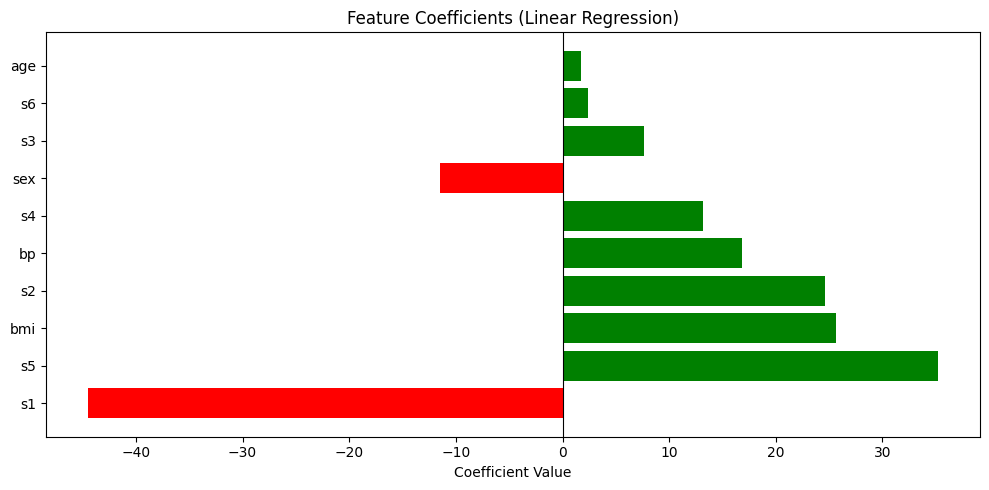

In [17]:
plt.figure(figsize=(10, 5))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients (Linear Regression)')
plt.tight_layout()
plt.show()

In [18]:
# Take one sample from test set and predict
sample = X_test_scaled[0].reshape(1, -1)
prediction = model.predict(sample)

print(f"Actual value:    {y_test.values[0]:.2f}")
print(f"Predicted value: {prediction[0]:.2f}")

Actual value:    219.00
Predicted value: 139.55
